# Anàlisi espectral i prosòdica

**Objectiu**: explorar si hi ha diferències espectrals (escala Mel) i prosòdiques (pitch i intensitat) entre els àudios de lectura de nens amb i sense dislèxia.

L'escala Mel aproxima la percepció auditiva humana, agrupant les freqüències en bandes perceptivament equidistants; diferències sistemàtiques en l'energia per bandes podrien indicar patrons articulatoris característics de la dislèxia. El segon bloc extreu característiques prosòdiques clíniques (freqüència fonamental i intensitat) amb Praat.

**Entrada**: fitxers `.wav` de `processed_data/`  
**Sortida**: `datasets/prosody_features_extracted.csv` amb les característiques prosòdiques per fitxer
**Mètode**: perfil Mel mitjà per fitxer (128 bandes, FFT de 1024 punts, hop de 256) + extracció prosòdica amb `parselmouth`

In [1]:
import os
import numpy as np
import pandas as pd
import librosa
from scipy.stats import ttest_ind

AUDIO_ROOT = './processed_data'
N_MELS = 128
N_FFT = 1024
HOP = 256
SR = 16000

def extract_mel_profile(file_path, ref=np.max):
    y, sr = librosa.load(file_path, sr=SR, mono=True)
    
    # Normalitzar amplitud abans (evita biaix de gravació)
    y = y / (np.max(np.abs(y)) + 1e-9)
    
    mel = librosa.feature.melspectrogram(
        y=y, sr=sr, n_mels=N_MELS, n_fft=N_FFT, hop_length=HOP
    )
    mel_db = librosa.power_to_db(mel, ref=ref)
    return mel_db.mean(axis=1)

# Recollir fitxers per grup
all_wavs = []
for root, _, files in os.walk(AUDIO_ROOT):
    for f in files:
        if f.lower().endswith('.wav'):
            all_wavs.append(os.path.join(root, f))

d_files = [f for f in all_wavs if 'D_' in os.path.basename(f)]
nod_files = [f for f in all_wavs if 'D_' not in os.path.basename(f)]

## 1. Perfils MEL per grup

Calculem el perfil MEL de cadascun dels fitxers seleccionats i n'obtenim la mitjana i la desviació estàndard per grup.

c:\Users\Marçal\OneDrive\Escriptori\TFG\dyslexia-detection\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
C:\Users\Marçal\AppData\Local\Temp\ipykernel_3444\1906128607.py:100: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax5.boxplot([global_D, global_noD],


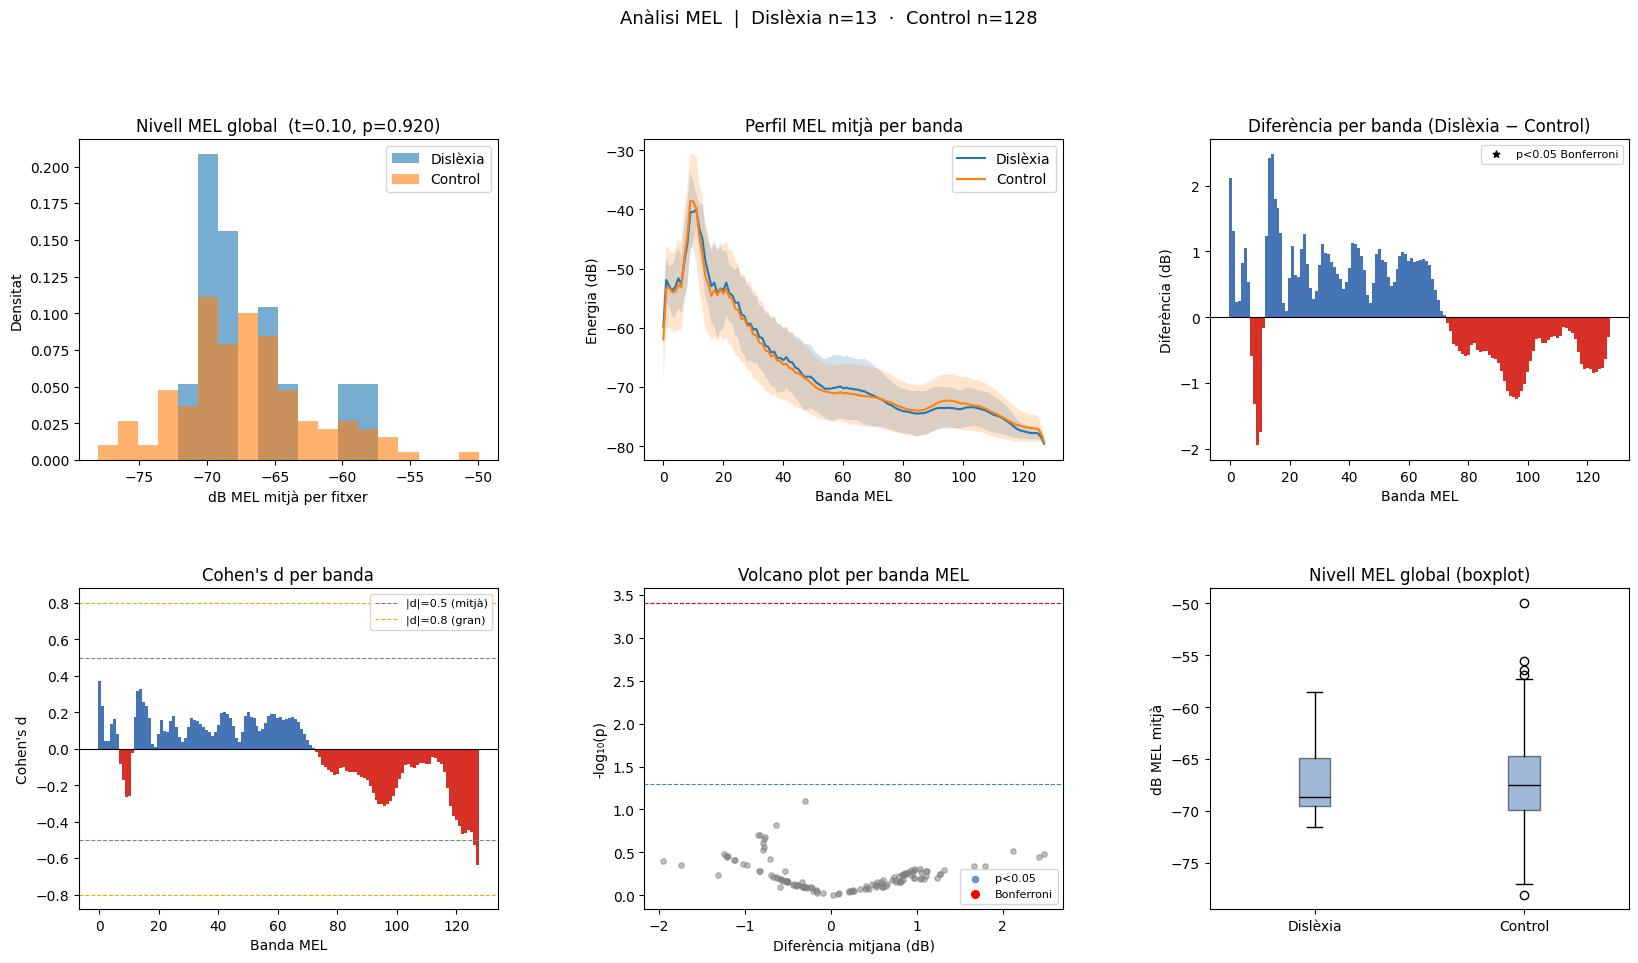

In [2]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.stats import ttest_ind

profiles_D   = np.vstack([extract_mel_profile(f) for f in d_files])
profiles_noD = np.vstack([extract_mel_profile(f) for f in nod_files])

mean_D,   std_D   = profiles_D.mean(axis=0),   profiles_D.std(axis=0)
mean_noD, std_noD = profiles_noD.mean(axis=0), profiles_noD.std(axis=0)
dif = mean_D - mean_noD

# Cohen's d per banda
pooled_std = np.sqrt((std_D**2 + std_noD**2) / 2)
cohens_d   = np.where(pooled_std > 0, dif / pooled_std, 0)

# p-valor per banda (sense correcció i amb Bonferroni)
pvals     = np.array([ttest_ind(profiles_D[:, i], profiles_noD[:, i]).pvalue
                      for i in range(N_MELS)])
sig_raw   = pvals < 0.05
sig_bonf  = pvals < (0.05 / N_MELS)

global_D   = profiles_D.mean(axis=1)
global_noD = profiles_noD.mean(axis=1)

mel_bins = np.arange(N_MELS)

# ── Layout ────────────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(20, 10))
gs  = gridspec.GridSpec(2, 3, hspace=0.4, wspace=0.35)

ax0 = fig.add_subplot(gs[0, 0])   # Histograma global
ax1 = fig.add_subplot(gs[0, 1])   # Perfil MEL mitjà
ax2 = fig.add_subplot(gs[0, 2])   # Diferència per banda
ax3 = fig.add_subplot(gs[1, 0])   # Cohen's d
ax4 = fig.add_subplot(gs[1, 1])   # -log10(p) per banda
ax5 = fig.add_subplot(gs[1, 2])   # Boxplot global

# ── Gràfic 0: Histograma global ───────────────────────────────────────────────
bins_hist = np.linspace(
    min(global_D.min(), global_noD.min()),
    max(global_D.max(), global_noD.max()), 20)
ax0.hist(global_D,   bins=bins_hist, alpha=0.6, label='Dislèxia', density=True)
ax0.hist(global_noD, bins=bins_hist, alpha=0.6, label='Control',  density=True)
t_glob, p_glob = ttest_ind(global_D, global_noD)
ax0.set_title(f'Nivell MEL global  (t={t_glob:.2f}, p={p_glob:.3f})')
ax0.set_xlabel('dB MEL mitjà per fitxer')
ax0.set_ylabel('Densitat')
ax0.legend()

# ── Gràfic 1: Perfil MEL mitjà ────────────────────────────────────────────────
ax1.plot(mel_bins, mean_D,   label='Dislèxia')
ax1.fill_between(mel_bins, mean_D   - std_D,   mean_D   + std_D,   alpha=0.2)
ax1.plot(mel_bins, mean_noD, label='Control')
ax1.fill_between(mel_bins, mean_noD - std_noD, mean_noD + std_noD, alpha=0.2)
ax1.set_title('Perfil MEL mitjà per banda')
ax1.set_xlabel('Banda MEL')
ax1.set_ylabel('Energia (dB)')
ax1.legend()

# ── Gràfic 2: Diferència per banda ────────────────────────────────────────────
colors = ['#d73027' if v < 0 else '#4575b4' for v in dif]
ax2.bar(mel_bins, dif, color=colors, width=1.0)
ax2.scatter(mel_bins[sig_bonf],
            dif[sig_bonf] + np.sign(dif[sig_bonf]) * 0.1,
            marker='*', color='black', s=25, zorder=5, label='p<0.05 Bonferroni')
ax2.axhline(0, color='black', lw=0.8)
ax2.set_title('Diferència per banda (Dislèxia − Control)')
ax2.set_xlabel('Banda MEL')
ax2.set_ylabel('Diferència (dB)')
ax2.legend(fontsize=8)

# ── Gràfic 3: Cohen's d ───────────────────────────────────────────────────────
colors_cd = ['#d73027' if v < 0 else '#4575b4' for v in cohens_d]
ax3.bar(mel_bins, cohens_d, color=colors_cd, width=1.0)
ax3.axhline( 0,    color='black',  lw=0.8)
ax3.axhline( 0.5,  color='gray',   lw=0.8, ls='--', label='|d|=0.5 (mitjà)')
ax3.axhline(-0.5,  color='gray',   lw=0.8, ls='--')
ax3.axhline( 0.8,  color='orange', lw=0.8, ls='--', label='|d|=0.8 (gran)')
ax3.axhline(-0.8,  color='orange', lw=0.8, ls='--')
ax3.set_title("Cohen's d per banda")
ax3.set_xlabel('Banda MEL')
ax3.set_ylabel("Cohen's d")
ax3.legend(fontsize=8)

# ── Gràfic 4: Volcano-style per banda ────────────────────────────────────────
log_p = -np.log10(pvals + 1e-300)
ax4.scatter(dif[~sig_raw],  log_p[~sig_raw],  alpha=0.5, s=15, color='gray')
ax4.scatter(dif[sig_raw],   log_p[sig_raw],   alpha=0.8, s=20, color='steelblue',
            label='p<0.05')
ax4.scatter(dif[sig_bonf],  log_p[sig_bonf],  alpha=1.0, s=30, color='red',
            label='Bonferroni')
ax4.axhline(-np.log10(0.05),          color='steelblue', ls='--', lw=0.8)
ax4.axhline(-np.log10(0.05 / N_MELS), color='red',       ls='--', lw=0.8)
ax4.set_title('Volcano plot per banda MEL')
ax4.set_xlabel('Diferència mitjana (dB)')
ax4.set_ylabel('-log₁₀(p)')
ax4.legend(fontsize=8)

# ── Gràfic 5: Boxplot nivell global ──────────────────────────────────────────
ax5.boxplot([global_D, global_noD],
            labels=['Dislèxia', 'Control'],
            patch_artist=True,
            boxprops=dict(facecolor='#4575b4', alpha=0.5),
            medianprops=dict(color='black'))
ax5.set_title('Nivell MEL global (boxplot)')
ax5.set_ylabel('dB MEL mitjà')

plt.suptitle(
    f'Anàlisi MEL  |  Dislèxia n={len(d_files)}  ·  Control n={len(nod_files)}',
    fontsize=13, y=1.01)
plt.show()

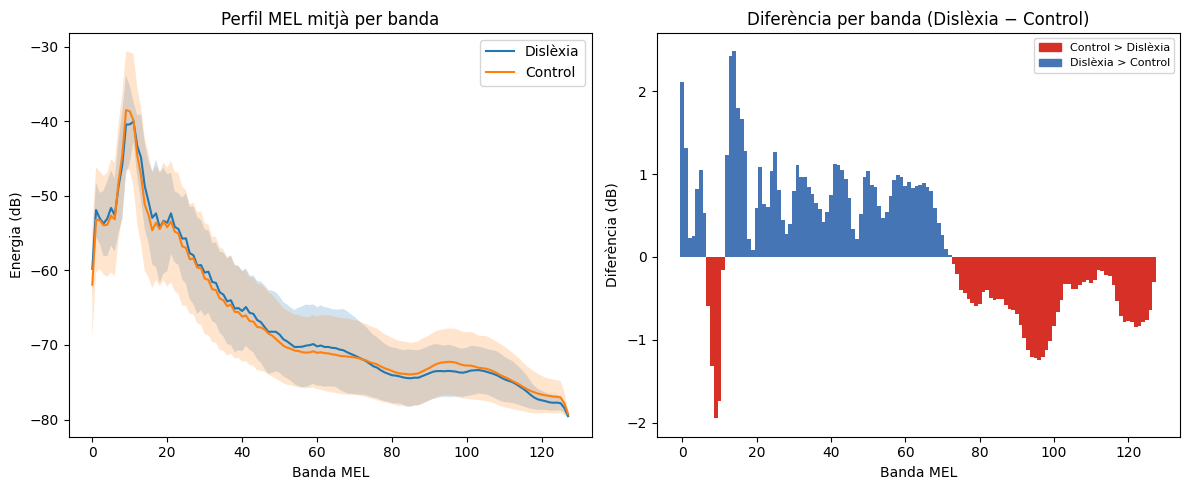

In [3]:
# Plot perfil MEL mitjà per banda i diferències per banda
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(mel_bins, mean_D, label='Dislèxia')
plt.fill_between(mel_bins, mean_D - std_D, mean_D + std_D, alpha=0.2)
plt.plot(mel_bins, mean_noD, label='Control')  
plt.fill_between(mel_bins, mean_noD - std_noD, mean_noD + std_noD, alpha=0.2)
plt.title('Perfil MEL mitjà per banda')
plt.xlabel('Banda MEL')
plt.ylabel('Energia (dB)')
plt.legend()
plt.subplot(1, 2, 2)
colors = ['#d73027' if v < 0 else '#4575b4' for v in dif]
plt.bar(mel_bins, dif, color=colors, width=1.0)
plt.title('Diferència per banda (Dislèxia − Control)')
plt.xlabel('Banda MEL')
plt.ylabel('Diferència (dB)')
# Legenda manual per a les barres
import matplotlib.patches as mpatches
red_patch = mpatches.Patch(color='#d73027', label='Control > Dislèxia')
blue_patch = mpatches.Patch(color='#4575b4', label='Dislèxia > Control')
plt.legend(handles=[red_patch, blue_patch], fontsize=8)
plt.tight_layout()
#plt.savefig('./imatges/prosody_mel_profile.pdf')
plt.show()

## 2. Comparació per macrobandes

Agrupar les 128 bandes en tres macrobandes (baixa, mitjana, alta) redueix el nombre de comparacions i dona una perspectiva global de les diferències.

In [4]:
import seaborn as sns

edges = np.linspace(0, N_MELS, 4, dtype=int)
band_labels = ['Baixa', 'Mitjana', 'Alta']

rows_plot = []
for i in range(3):
    start, end = edges[i], edges[i + 1]
    d_vals = profiles_D[:, start:end].mean(axis=1)
    nd_vals = profiles_noD[:, start:end].mean(axis=1)
    for v in d_vals:
        rows_plot.append({'Macrobanda': band_labels[i], 'Grup': 'Dislèxia', 'Energia': v})
    for v in nd_vals:
        rows_plot.append({'Macrobanda': band_labels[i], 'Grup': 'Control', 'Energia': v})

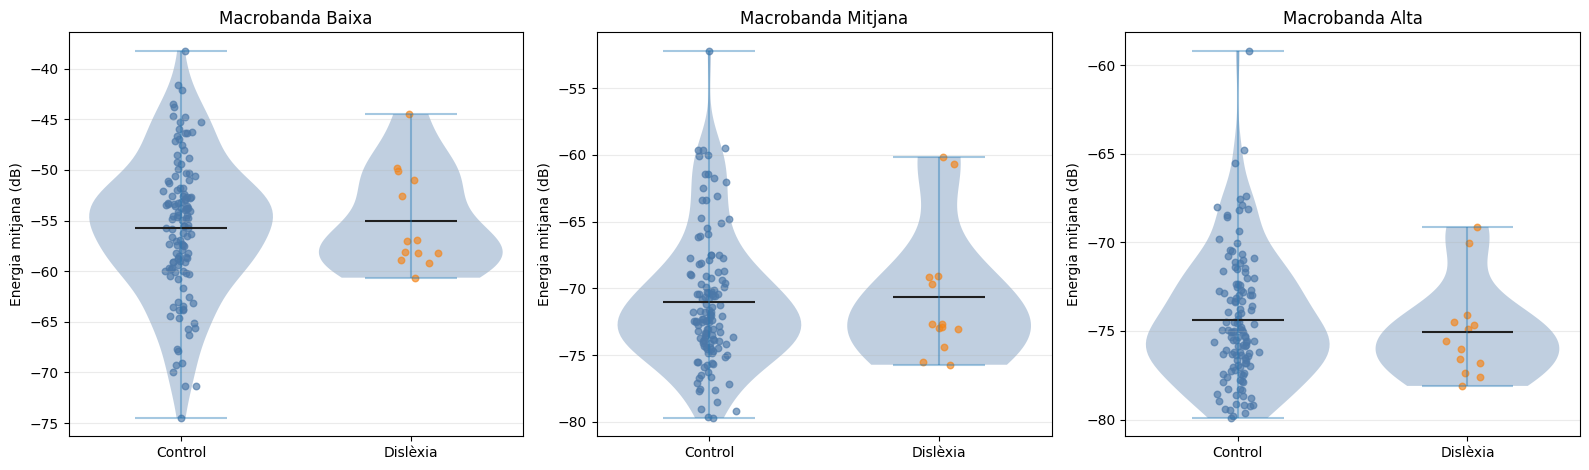

In [5]:
# Visualització tipus violin + punts per macrobandes MEL
import numpy as np
import matplotlib.pyplot as plt

df_plot = pd.DataFrame(rows_plot)

macro_order = ["Baixa", "Mitjana", "Alta"]

fig, axes = plt.subplots(1, 3, figsize=(16, 4.8))
axes = np.atleast_1d(axes).flatten()

rng = np.random.default_rng(42)

for ax, band in zip(axes, macro_order):

    sub = df_plot[df_plot["Macrobanda"] == band]

    non_vals = sub.loc[sub["Grup"] == "Control", "Energia"].dropna().to_numpy()
    dys_vals = sub.loc[sub["Grup"] == "Dislèxia", "Energia"].dropna().to_numpy()

    if len(non_vals) > 0 and len(dys_vals) > 0:

        # violin plot
        parts = ax.violinplot(
            [non_vals, dys_vals],
            positions=[1, 2],
            showmeans=True,
            showextrema=True,
            widths=0.8
        )

        for pc in parts["bodies"]:
            pc.set_facecolor("#4C78A8")
            pc.set_alpha(0.35)

        parts["cmeans"].set_color("#1F1F1F")
        parts["cbars"].set_alpha(0.4)
        parts["cmins"].set_alpha(0.4)
        parts["cmaxes"].set_alpha(0.4)

        # punts individuals
        x_non = rng.normal(1, 0.04, size=len(non_vals))
        x_dys = rng.normal(2, 0.04, size=len(dys_vals))

        ax.scatter(
            x_non, non_vals,
            alpha=0.65, s=22,
            color="#4C78A8"
        )

        ax.scatter(
            x_dys, dys_vals,
            alpha=0.65, s=22,
            color="#F58518"
        )

        ax.set_xticks([1, 2])
        ax.set_xticklabels(["Control", "Dislèxia"])
        ax.set_title(f"Macrobanda {band}")
        ax.set_ylabel("Energia mitjana (dB)")
        ax.grid(axis="y", alpha=0.25)

    else:
        ax.text(0.5, 0.5, "Not enough data", ha="center", va="center")
        ax.set_axis_off()

plt.tight_layout()
plt.savefig("./imatges/violin_mel_bands.pdf")
plt.show()

In [6]:
from scipy.stats import ttest_ind

def fdr_bh(p_values):
    '''Correcció de Benjamini-Hochberg per comparacions múltiples.'''
    p = np.asarray(p_values, dtype=float)
    m = len(p)
    order = np.argsort(p)
    p_sorted = p[order]
    prev, q_sorted = 1.0, np.empty(m)
    for i in range(m - 1, -1, -1):
        prev = min(prev, (m / (i + 1)) * p_sorted[i])
        q_sorted[i] = prev
    q = np.empty(m)
    q[order] = np.minimum(q_sorted, 1.0)
    return q


def hedges_g(x, y):
    '''Mida d\'efecte de Hedges g.'''
    x, y = np.asarray(x)[np.isfinite(np.asarray(x))], np.asarray(y)[np.isfinite(np.asarray(y))]
    if len(x) < 2 or len(y) < 2:
        return np.nan
    n1, n2 = len(x), len(y)
    s_pool = np.sqrt(((n1 - 1) * np.var(x, ddof=1) + (n2 - 1) * np.var(y, ddof=1)) / (n1 + n2 - 2))
    if s_pool == 0:
        return 0.0
    d = (np.mean(x) - np.mean(y)) / s_pool
    return d * (1 - 3 / (4 * (n1 + n2) - 9))


rows_stats = []
for i in range(3):
    start, end = edges[i], edges[i + 1]
    d_vals = profiles_D[:, start:end].mean(axis=1)
    nd_vals = profiles_noD[:, start:end].mean(axis=1)
    if len(nd_vals) >= 2 and len(d_vals) >= 2:
        t_stat, p_val = ttest_ind(d_vals, nd_vals, equal_var=False)
    else:
        t_stat, p_val = np.nan, np.nan
    rows_stats.append({
        'variable': band_labels[i],
        'n_control': len(nd_vals),
        'n_dislexia': len(d_vals),
        'mitjana_control': nd_vals.mean() if len(nd_vals) else np.nan,
        'mitjana_dislexia': d_vals.mean() if len(d_vals) else np.nan,
        'diferencia': (d_vals.mean() - nd_vals.mean()) if (len(nd_vals) and len(d_vals)) else np.nan,
        't_stat': t_stat,
        'p_value': p_val,
        'hedges_g': hedges_g(d_vals, nd_vals),
    })

df_stats = pd.DataFrame(rows_stats)
valid = df_stats['p_value'].notna()
q_vals = np.full(len(df_stats), np.nan)
if valid.sum() > 0:
    q_vals[valid] = fdr_bh(df_stats.loc[valid, 'p_value'].values)
df_stats['q_value_fdr'] = q_vals
df_stats['significatiu_fdr'] = df_stats['q_value_fdr'] < 0.05
df_stats = df_stats.sort_values('p_value')

print('=== Resultats estadístics (Welch t-test + FDR-BH) ===')
display(df_stats.set_index('variable').round(4))

sig = df_stats[df_stats['significatiu_fdr']]
print(f'\nVariables significatives (q<0.05): {len(sig)}')
if len(sig) > 0:
    for _, r in sig.iterrows():
        print(f'  {r["variable"]}: g={r["hedges_g"]:.3f}, q={r["q_value_fdr"]:.4f}')

=== Resultats estadístics (Welch t-test + FDR-BH) ===


,n_control,n_dislexia,mitjana_control,mitjana_dislexia,diferencia,t_stat,p_value,hedges_g,q_value_fdr,significatiu_fdr
variable,,,,,,,,,,
Alta,128,13,-74.398201,-75.031898,-0.6337,-0.7729,0.4506,-0.1817,0.7918,False
Baixa,128,13,-55.693699,-55.016998,0.6766,0.4565,0.6538,0.1013,0.7918,False
Mitjana,128,13,-71.050400,-70.657799,0.3926,0.2689,0.7918,0.0796,0.7918,False



Variables significatives (q<0.05): 0


## 3. Característiques prosòdiques clíniques (Praat)

Aquest bloc documenta de manera reproduïble l'extracció i la comparació de característiques prosòdiques entre grups, extretes amb Praat (`parselmouth`):

- **Característiques**: `f0_mean`, `f0_std` (freqüència fonamental) i `int_mean`, `int_std` (intensitat).
- **Etiquetatge**: automàtic pel prefix `D_` al nom del fitxer.
- **Anàlisi**: estadística descriptiva + contrast inferencial (Welch t-test) + correcció FDR-BH + mida d'efecte (Hedges g).

In [10]:
import os
import numpy as np
import pandas as pd
import parselmouth
from parselmouth.praat import call

def extract_clinical_prosody(audio_path, pitch_floor=75, pitch_ceiling=500):
    """Extreu caracteristiques prosodiques robustes d'un fitxer d'audio."""
    snd = parselmouth.Sound(audio_path)

    # 1) Pitch
    pitch = snd.to_pitch(pitch_floor=pitch_floor, pitch_ceiling=pitch_ceiling)
    f0_all = pitch.selected_array['frequency']
    f0_voiced = f0_all[f0_all > 0]

    if len(f0_voiced) > 0:
        f0_mean = float(np.nanmean(f0_voiced))
        f0_std = float(np.nanstd(f0_voiced))
    else:
        f0_mean = np.nan
        f0_std = np.nan

    # 2) Intensitat
    intensity = snd.to_intensity()
    int_values = intensity.values[0]
    intensity_mean_db = float(np.nanmean(int_values))
    intensity_std_db = float(np.nanstd(int_values))


    return {
        "f0_mean": f0_mean,
        "f0_std": f0_std,
        "int_mean": intensity_mean_db,
        "int_std": intensity_std_db,
    }

In [11]:
# Construccio del dataset prosodic
audio_root = "./processed_data"
max_files_per_group = None  # Ex: 30 per proves rapides; None per usar-ho tot
rng = np.random.default_rng(42)

all_wavs = []
for root, _, files in os.walk(audio_root):
    for file in files:
        if file.lower().endswith(".wav"):
            all_wavs.append(os.path.join(root, file))

if not all_wavs:
    raise ValueError("No s'han trobat fitxers .wav a processed_data")

d_files = sorted([f for f in all_wavs if "D_" in os.path.basename(f)])
nod_files = sorted([f for f in all_wavs if "D_" not in os.path.basename(f)])

if max_files_per_group is not None:
    d_n = min(max_files_per_group, len(d_files))
    nod_n = min(max_files_per_group, len(nod_files))
    d_files = list(rng.choice(d_files, size=d_n, replace=False))
    nod_files = list(rng.choice(nod_files, size=nod_n, replace=False))

selected_files = d_files + nod_files
records = []
for i, wav in enumerate(selected_files, start=1):
    if i % 20 == 0 or i == len(selected_files):
        print(f"Processant {i}/{len(selected_files)}")

    feats = extract_clinical_prosody(wav)
    label = 1 if "D_" in os.path.basename(wav) else 0
    feats.update({
        "file_path": wav,
        "file_name": os.path.basename(wav),
        "label": label,
        "group": "D" if label == 1 else "noD",
    })
    records.append(feats)

df_prosody = pd.DataFrame(records)
df_prosody = df_prosody.replace([np.inf, -np.inf], np.nan)

feature_cols = [
    "f0_mean", "f0_std",
    "int_mean", "int_std"
]

print(f"Total fitxers analitzats: {len(df_prosody)}")
print(df_prosody["group"].value_counts())
df_prosody.head()

Processant 20/141
Processant 40/141
Processant 60/141
Processant 80/141
Processant 100/141
Processant 120/141
Processant 140/141
Processant 141/141
Total fitxers analitzats: 141
group
noD    128
D       13
Name: count, dtype: int64


,f0_mean,f0_std,int_mean,int_std,file_path,file_name,label,group
0,270.875368,41.072632,60.700673,15.148046,./processed_data\Escola 1\3A\D_Alex9 - Los oka...,D_Alex9 - Los okapis (Castellano) - LlM_ (Cata...,1,D
1,248.971093,63.856082,64.535656,10.415275,./processed_data\Escola 1\3A\D_Arnau8 - Los ok...,D_Arnau8 - Los okapis (Castellano) - LlM_ (Cat...,1,D
2,297.497443,54.345102,64.186044,12.439623,./processed_data\Escola 1\3A\D_Berta8 - Los ok...,D_Berta8 - Los okapis (Castellano) - LlM_ (Cas...,1,D
3,229.087997,58.125067,64.643706,9.660529,./processed_data\Escola 1\3A\D_Lena8 - Los oka...,D_Lena8 - Los okapis (Castellano) - LlM_ (Cata...,1,D
4,296.799682,43.632072,61.693896,13.531231,./processed_data\Escola 1\3B\D_Ivet9 - Los oka...,D_Ivet9 - Los okapis (Castellano) - LlM_ (Cata...,1,D


In [12]:
# Resum descriptiu
os.makedirs("datasets", exist_ok=True)

summary_by_group = df_prosody.groupby("group")[feature_cols].agg(["mean", "std", "median"])

print("Resum descriptiu per grup (mean/std/median):")
display(summary_by_group)

df_prosody.to_csv("datasets/prosody_features_extracted.csv", index=False)

print("Arxius guardats a datasets/: prosody_features_extracted.csv")

Resum descriptiu per grup (mean/std/median):


f0_mean                            f0_std                        \
             mean        std      median       mean        std     median   
group                                                                       
D      261.083894  32.319564  251.735905  52.905836  13.437279  52.985545   
noD    250.284472  30.684092  252.410107  47.540120  14.929444  45.100805   

        int_mean                          int_std                        
            mean        std     median       mean        std     median  
group                                                                    
D      62.897305   3.987607  62.544556  13.877375   2.999082  15.148046  
noD    58.456451  14.556476  62.483010  19.594335  21.986515  13.942407

Arxius guardats a datasets/: prosody_features_extracted.csv


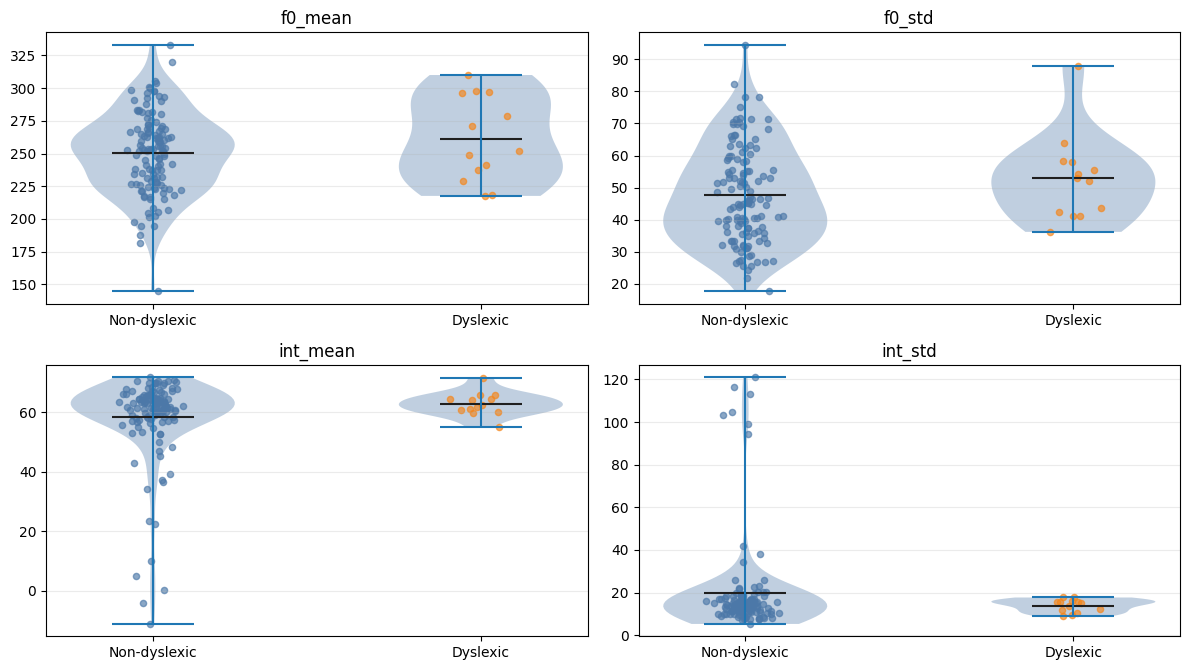

In [ ]:
import matplotlib.pyplot as plt

if df_prosody.empty:
    print("No data available for additional visualizations.")
else:
    metric_cols = [
        "f0_mean",
        "f0_std",
        "int_mean",
        "int_std"
    ]

    df_vis = df_prosody.copy()
    # Rename "Group"
    df_vis["Group"] = np.where(df_vis["group"] == "D", "Dyslexic", "Non-dyslexic")

    # Create only the necessary subplot grid and remove extras
    n_metrics = len(metric_cols)
    ncols = 2
    nrows = int(np.ceil(n_metrics / ncols))

    fig, axes = plt.subplots(nrows, ncols, figsize=(12, 3.4 * nrows))
    axes = np.atleast_1d(axes).flatten()

    rng = np.random.default_rng(42)

    for ax, col in zip(axes, metric_cols):
        non_vals = df_vis.loc[df_vis["Group"] == "Non-dyslexic", col].dropna().to_numpy()
        dys_vals = df_vis.loc[df_vis["Group"] == "Dyslexic", col].dropna().to_numpy()

        if len(non_vals) > 0 and len(dys_vals) > 0:
            parts = ax.violinplot([non_vals, dys_vals], positions=[1, 2], showmeans=True, showextrema=True)
            for pc in parts["bodies"]:
                pc.set_alpha(0.35)
                pc.set_facecolor("#4C78A8")
            parts["cmeans"].set_color("#1F1F1F")

            x_non = rng.normal(1, 0.04, size=len(non_vals))
            x_dys = rng.normal(2, 0.04, size=len(dys_vals))
            ax.scatter(x_non, non_vals, alpha=0.65, s=20, color="#4C78A8")
            ax.scatter(x_dys, dys_vals, alpha=0.65, s=20, color="#F58518")

            ax.set_xticks([1, 2])
            ax.set_xticklabels(["Non-dyslexic", "Dyslexic"])
            ax.set_title(f"{col}")
            ax.grid(axis="y", alpha=0.25)
        else:
            ax.text(0.5, 0.5, "Not enough data", ha="center", va="center")
            ax.set_title(f"{col}")
            ax.set_axis_off()

    # Remove unused axes so no empty plots are shown
    for ax in axes[n_metrics:]:
        fig.delaxes(ax)

    plt.tight_layout()
    #plt.savefig("./imatges/prosody_violin_plots.pdf")
    plt.show()


In [15]:
# Inferencia estadistica per caracteristica (Welch + FDR + Hedges g)
from scipy.stats import ttest_ind

def fdr_bh(p_values):
    p = np.asarray(p_values, dtype=float)
    m = len(p)
    order = np.argsort(p)
    p_sorted = p[order]

    q_sorted = np.empty(m, dtype=float)
    prev = 1.0
    for i in range(m - 1, -1, -1):
        rank = i + 1
        q_val = (m / rank) * p_sorted[i]
        prev = min(prev, q_val)
        q_sorted[i] = prev

    q_values = np.empty(m, dtype=float)
    q_values[order] = np.minimum(q_sorted, 1.0)
    return q_values

def hedges_g(x, y):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    x = x[np.isfinite(x)]
    y = y[np.isfinite(y)]
    if len(x) < 2 or len(y) < 2:
        return np.nan

    n1, n2 = len(x), len(y)
    s1, s2 = np.var(x, ddof=1), np.var(y, ddof=1)
    pooled_sd = np.sqrt(((n1 - 1) * s1 + (n2 - 1) * s2) / (n1 + n2 - 2))
    if pooled_sd == 0:
        return 0.0

    d = (np.mean(x) - np.mean(y)) / pooled_sd
    correction = 1 - (3 / (4 * (n1 + n2) - 9))
    return d * correction

rows = []
for feat in feature_cols:
    d_vals = df_prosody.loc[df_prosody["group"] == "D", feat].dropna()
    nod_vals = df_prosody.loc[df_prosody["group"] == "noD", feat].dropna()

    if len(d_vals) >= 2 and len(nod_vals) >= 2:
        t_stat, p_val = ttest_ind(d_vals, nod_vals, equal_var=False)
    else:
        t_stat, p_val = np.nan, np.nan

    rows.append({
        "feature": feat,
        "n_D": len(d_vals),
        "n_noD": len(nod_vals),
        "mean_D": d_vals.mean() if len(d_vals) else np.nan,
        "mean_noD": nod_vals.mean() if len(nod_vals) else np.nan,
        "diff_D_minus_noD": (d_vals.mean() - nod_vals.mean()) if (len(d_vals) and len(nod_vals)) else np.nan,
        "t_stat": t_stat,
        "p_value": p_val,
        "hedges_g": hedges_g(d_vals, nod_vals),
    })

df_stats_prosody = pd.DataFrame(rows)

valid_mask = df_stats_prosody["p_value"].notna()
q_vals = np.full(len(df_stats_prosody), np.nan)
if valid_mask.sum() > 0:
    q_vals[valid_mask] = fdr_bh(df_stats_prosody.loc[valid_mask, "p_value"].values)
df_stats_prosody["q_value_fdr"] = q_vals
df_stats_prosody["significant_fdr_0_05"] = df_stats_prosody["q_value_fdr"] < 0.05

df_stats_prosody = df_stats_prosody.sort_values(["q_value_fdr", "p_value"], na_position="last")
display(df_stats_prosody)

,feature,n_D,n_noD,mean_D,mean_noD,diff_D_minus_noD,t_stat,p_value,hedges_g,q_value_fdr,significant_fdr_0_05
3,int_std,13,128,13.877375,19.594335,-5.716959,-2.704483,0.007749,-0.270320,0.022681,True
2,int_mean,13,128,62.897305,58.456451,4.440854,2.617456,0.011340,0.316321,0.022681,True
1,f0_std,13,128,52.905836,47.540120,5.365716,1.357188,0.194566,0.360429,0.259421,False
0,f0_mean,13,128,261.083894,250.284472,10.799423,1.153151,0.267778,0.348411,0.267778,False
